In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import torch
from tqdm import tqdm

from tarp import get_tarp_coverage
from mira_score import get_device, mira, mira_bootstrap

# 5.1: Baseline Comparison

In [2]:
rng = np.random.default_rng(42)  # Fixed seed

# ------------------------------------------------
# Global settings
# ------------------------------------------------
L = 1000      # number of ground-truth draws
N = 500       # posterior samples per GT
D = 1000      # number of TARP references
dim = 2

# ------------------------------------------------
# Define colors for the cases
# ------------------------------------------------
# Define consistent colors for each case
case_colors = {
    'Correct': 'tab:blue',
    'Overconfident': 'tab:orange', 
    'Underconfident': 'tab:green',
    'Biased': 'tab:red'
}

# ------------------------------------------------
# θ* and Σ (Σ = diag(σ^2))
# ------------------------------------------------
theta_star = rng.uniform(-5, 5, size=(L, dim))
log_sigma = rng.uniform(-5, -1, size=(L, dim))
sigma = np.exp(log_sigma)                               
Sigma = np.array([np.diag(s**2) for s in sigma])        

# ------------------------------------------------
# Helper: draw "true" parameter values once per GT
# ------------------------------------------------
def draw_true(theta_star, Sigma, scale=1.0):
    out = []
    for mu, cov in zip(theta_star, Sigma):
        out.append(rng.multivariate_normal(mu, cov * scale))
    return np.stack(out)                                 

# ------------------------------------------------
# Paper bias term for the biased case (element-wise)
# bias = sign(θ*) * Z(1 - |θ*|/5) * σ
# ------------------------------------------------
def paper_bias(mu, cov, bias_strength=1.0, eps=1e-9):
    s = np.sqrt(np.diag(cov))                            
    alpha = np.clip(1.0 - np.abs(mu)/5.0, eps, 1.0 - eps)
    Z = norm.isf(alpha)
    return bias_strength * np.sign(mu) * Z * s

# ------------------------------------------------
# Truncated multivariate normal sampler
# ------------------------------------------------
def truncated_multivariate_normal(mean, cov, N, low=-5, high=5):
    d = len(mean)
    samples = []

    while len(samples) < N:
        x = np.random.multivariate_normal(mean, cov)
        if np.all(x >= low) and np.all(x <= high):
            samples.append(x)

    return np.array(samples)

# ------------------------------------------------
# Posterior draws from the estimator  N(mean, Σ)
# (Σ is unchanged across cases; only mean is shifted for "biased")
# ------------------------------------------------
def sample_posts(theta_star, Sigma, biased=False, bias_strength=1.0):
    posts = []
    for mu, cov in zip(theta_star, Sigma):
        m = mu - paper_bias(mu, cov, bias_strength) if biased else mu
        posts.append(truncated_multivariate_normal(m, cov,N))
    return np.stack(posts)

# ------------------------------------------------
# Build the four cases exactly as in §4.1
# ------------------------------------------------
theta_true_correct = draw_true(theta_star, Sigma, 1.0)   # correct
theta_true_over    = draw_true(theta_star, Sigma, 3.0)   # truth wider    -> posterior too narrow  (overconfident)
theta_true_under   = draw_true(theta_star, Sigma, 0.5)   # truth narrower -> posterior too wide   (underconfident)
theta_true_biased  = draw_true(theta_star, Sigma, 1.0)   # biased

posts_correct = sample_posts(theta_star, Sigma, biased=False)
posts_over    = sample_posts(theta_star, Sigma, biased=False)
posts_under   = sample_posts(theta_star, Sigma, biased=False)
posts_biased = sample_posts(theta_star, Sigma, biased=True, bias_strength=5.0)

def to_SND(arr): 
    return np.transpose(arr, (1, 0, 2))

posts_correct = to_SND(posts_correct)
posts_over    = to_SND(posts_over)
posts_under   = to_SND(posts_under)
posts_biased  = to_SND(posts_biased)

# ------------------------------------------------
# TARP references
# ------------------------------------------------
references = rng.uniform(-5, 5, size=(D, dim))

100%|██████████| 100/100 [00:01<00:00, 59.93it/s]


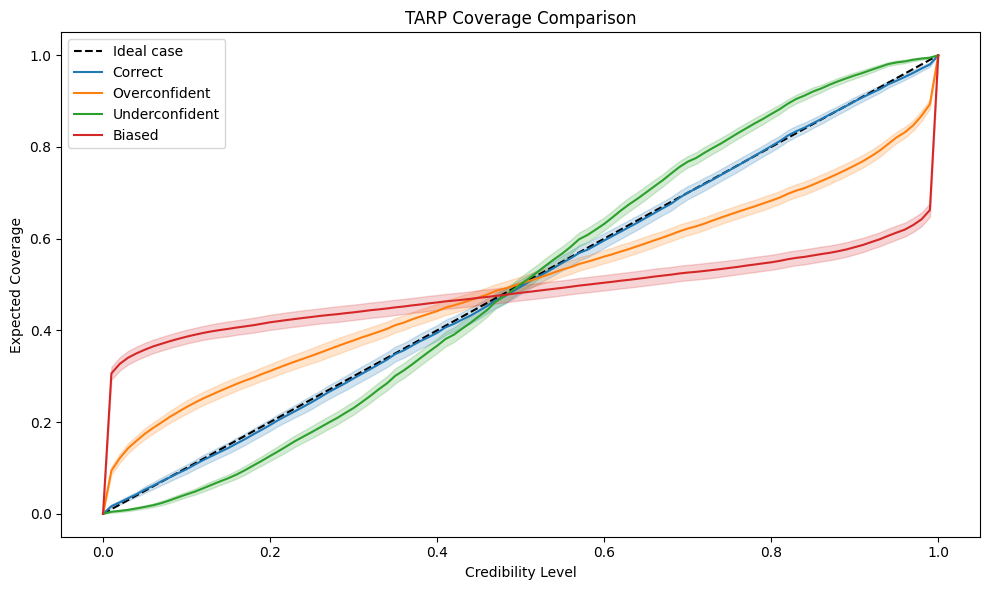

In [3]:
posterior_sets = [
    (posts_correct,  theta_true_correct, "Correct"),
    (posts_over,     theta_true_over,    "Overconfident"),
    (posts_under,    theta_true_under,   "Underconfident"),
    (posts_biased,   theta_true_biased,  "Biased"),
]
 
# Convert references back to numpy if needed
if isinstance(references, torch.Tensor):
    references_np = references.cpu().numpy()
else:
    references_np = references

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")

for posts, theta_true, title in posterior_sets:
    ecp, alpha = get_tarp_coverage(
        posts, theta_true, 
        references=references_np,
        metric="euclidean", norm=True,
    )
    ecp_bootstrap, alpha_bootstrap = get_tarp_coverage(
        posts, theta_true, 
        references=references_np,
        metric="euclidean", norm=True, bootstrap=True,
    )
    
    color = case_colors[title]  # Use consistent color
    ax.plot(alpha, ecp_bootstrap.mean(axis=0), label=title, color=color)
    

    ax.fill_between(
        alpha, 
        ecp_bootstrap.mean(axis=0) - 1 * ecp_bootstrap.std(axis=0), 
        ecp_bootstrap.mean(axis=0) + 1 * ecp_bootstrap.std(axis=0), 
        alpha=0.2, color=color  # Match fill color
    )

ax.set_xlabel("Credibility Level")
ax.set_ylabel("Expected Coverage")
ax.set_title("TARP Coverage Comparison")
ax.legend()

plt.tight_layout()
plt.show()

Using device: mps


Mira MC runs: 100%|██████████| 100/100 [00:00<00:00, 362.80it/s]


Mira Score for the Correct case: 0.6674351692199707 ± 0.00735457893460989


Mira MC runs: 100%|██████████| 100/100 [00:00<00:00, 1107.95it/s]


Mira Score for the Overconfident case: 0.6159669160842896 ± 0.00706168869510293


Mira MC runs: 100%|██████████| 100/100 [00:00<00:00, 1109.18it/s]

Mira Score for the Underconfident case: 0.693901538848877 ± 0.00643891142681241



Mira MC runs: 100%|██████████| 100/100 [00:00<00:00, 1144.18it/s]


Mira Score for the Biased case: 0.544400155544281 ± 0.008334452286362648


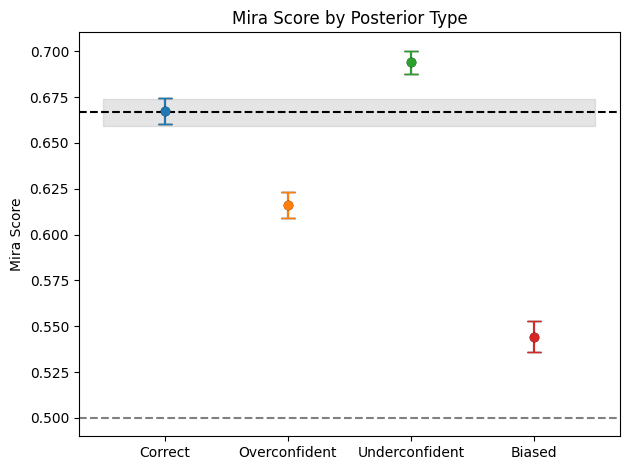

In [4]:
# -------------------------------
# 4. Mira Evaluation
# -------------------------------
device = get_device()
print("Using device:", device)

# FOR Mira --> (num_gt, num_samples, dim)
mira_posteriors = np.array([
    np.transpose(posts_correct, (1, 0, 2)), 
    np.transpose(posts_over, (1, 0, 2)), 
    np.transpose(posts_under, (1, 0, 2)), 
    np.transpose(posts_biased, (1, 0, 2))
])

# Make references a torch tensor
references = torch.tensor(references, dtype=torch.float32, device=get_device())
list_of_cases = ['Correct', 'Overconfident', 'Underconfident', 'Biased']

mira_scores_list = []
mira_score_std_list = []
for i, case in enumerate(list_of_cases):
    # Make the current mira posterior --> Add a 1 to the front to make it (1, num_gt, num_samples, dim)
    curr_mira = mira_posteriors[i][np.newaxis, :, :, :]
    posterior_norm = curr_mira
    gt_norm = [theta_true_correct, theta_true_over, theta_true_under, theta_true_biased][i]

    # Convert to torch Tensors on the chosen device
    posterior_norm   = torch.tensor(posterior_norm, dtype=torch.float32, device=device)
    gt_norm = torch.tensor(gt_norm,   dtype=torch.float32, device=device)


    mira_score_mean, mira_score_std = mira(
        gt_norm, 
        posterior_norm, 
        num_runs=100, norm=True
    )

    print(f'Mira Score for the {list_of_cases[i]} case: {mira_score_mean[0].cpu().numpy()} ± {mira_score_std[0].cpu().numpy()}')

    mira_scores_list.append(mira_score_mean)
    mira_score_std_list.append(mira_score_std)

# Convert results, calibrated, n_over_N_vals back to numpy arrays
mira_scores = [score.cpu().numpy() for score in mira_scores_list]
mira_score_stds = [score.cpu().numpy() for score in mira_score_std_list]

scores = np.array(mira_scores).flatten()
stds   = np.array(mira_score_stds).flatten()

x_labels = ['Correct', 'Overconfident', 'Underconfident', 'Biased']
x_vals = np.arange(len(x_labels)) 

colors = [case_colors[label] for label in x_labels]

plt.errorbar(x_labels, scores, yerr=stds, fmt='o', capsize=5, 
             color='black', ecolor='black')  # Or use individual colors below

# For individual colored markers:
for i, (label, score, std) in enumerate(zip(x_labels, scores, stds)):
    plt.errorbar(label, score, yerr=std, fmt='o', capsize=5, 
                 color=case_colors[label], ecolor=case_colors[label])

# Calibration reference lines
plt.axhline(y=1/2, color='gray', linestyle='--')
plt.axhline(y=2/3, color='black', linestyle='--')

variance = (1/18) / L
std = np.sqrt(variance)
support = np.linspace(x_vals[0] - 0.5, x_vals[-1] + 0.5, 100)

plt.fill_between(
    support,
    2/3 - std,
    2/3 + std,
    color='gray',
    alpha=0.2,
)

# Final plot touches
plt.xticks(x_vals, x_labels)
plt.ylabel('Mira Score')
plt.title('Mira Score by Posterior Type')
plt.tight_layout()
plt.show()